In [1]:
#!git clone https://github.com/Rorschach1989/nfm.git

Cloning into 'nfm'...
remote: Enumerating objects: 694, done.
remote: Counting objects: 100% (381/381), done.
remote: Compressing objects: 100% (240/240), done.
remote: Total 694 (delta 250), reused 232 (delta 139), pack-reused 313 (from 1)
Receiving objects: 100% (694/694), 3.58 MiB | 5.74 MiB/s, done.
Resolving deltas: 100% (471/471), done.


In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader
from nfm.nfm.DatasetsDHS import SurvivalDataset
from nfm.nfm.base import MonotoneNLL
from nfm.nfm.eps_config import IGGEps
from nfm.nfm.metric import c_index
from nfm.nfm.utils import default_device
from pycox.evaluation.eval_surv import EvalSurv


data_full = SurvivalDataset.Zimbabwe('./nfm/data/Zimbabwe_cleanednew.csv')
fold_c_indices = []
fold_survival =  []
fold_ibs = []
fold_nbll = []
normalizing_factor = 366.25


def normalize(y):
    return (y + 1) / normalizing_factor


n_hidden = 128
n_hidden_umnn = 128


for i in tqdm(range(5)):
    torch.manual_seed(77+i)
    train_folds, valid_folds, test_folds = data_full.cv_split(shuffle=True)
    for i in range(5):
        test_c_indices, test_ibs, test_nbll = [], [], []
        valid_losses = []
        m = nn.Sequential(
            nn.Linear(in_features=475, out_features=n_hidden, bias=False),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=n_hidden, out_features=1, bias=False),
        ).to(default_device)
        nll = MonotoneNLL(eps_conf=IGGEps(),
                          num_hidden_units=n_hidden_umnn,
                          positive_transform='exp').to(default_device)
        optimizer = torch.optim.Adam(lr=1e-3, weight_decay=1e-2, params=list(m.parameters()) + list(nll.parameters()))
        loader = DataLoader(train_folds[i], batch_size=256)
        for epoch in range(30):
            for z, y, delta in loader:
                m.train()
                m_z = m(z)
                loss = nll(m_z=m_z, y=normalize(y), delta=delta)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            m.eval()
            with torch.no_grad():
                y_valid, delta_valid, z_valid = valid_folds[i].sort()
                y_test, delta_test, z_test = test_folds[i].sort()
                y_valid, y_test = normalize(y_valid), normalize(y_test)
                pred_valid = m(z_valid)
                pred_test = m(z_test)
                valid_loss = nll(pred_valid, y_valid, delta_valid)
                valid_losses.append(valid_loss)
                tg_test = np.linspace(y_test.cpu().numpy().min(), y_test.cpu().numpy().max(), 60)
                surv_pred_test = nll.get_survival_prediction(
                    pred_test, y_test=torch.tensor(tg_test, dtype=torch.float).view(-1, 1))
                test_evaluator = EvalSurv(
                    surv=pd.DataFrame(surv_pred_test.cpu().numpy(), index=tg_test.reshape(-1)),
                    durations=y_test.cpu().numpy().reshape(-1),
                    events=delta_test.cpu().numpy().reshape(-1),
                    censor_surv='km')
                test_c_indices.append(c_index(-pred_test, y_test, delta_test))
                test_ibs.append(test_evaluator.integrated_brier_score(time_grid=tg_test))
                test_nbll.append(test_evaluator.integrated_nbll(time_grid=tg_test))
        valid_argmin = np.argmin(valid_losses)
        fold_survival.append(np.asarray(surv_pred_test)[valid_argmin])
        fold_c_indices.append(np.asarray(test_c_indices)[valid_argmin])
        fold_ibs.append(np.asarray(test_ibs)[valid_argmin])
        fold_nbll.append(np.asarray(test_nbll)[valid_argmin])


report_str = f"""
Results:
    mean survival: {np.asarray(fold_survival).mean()}
    mean c-index: {np.asarray(fold_c_indices).mean()}
    std c-index: {np.asarray(fold_c_indices).std()}
    mean ibs: {np.asarray(fold_ibs).mean()}
    std ibs: {np.asarray(fold_ibs).std()}
    mean ibll: {np.asarray(fold_nbll).mean()}
    std ibll: {np.asarray(fold_nbll).std()}
"""
print(report_str)


/home/justine/miniconda3/envs/py37/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|                                                                                             | 0/5 [00:00<?, ?it/s]/home/justine/nfm/nfm/DatasetsDHS.py:313: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float, device=default_device).view(-1, 1)
/home/justine/nfm/nfm/DatasetsDHS.py:314: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.delta = torch.tensor(delta, dtype=torch.float, d

ValueError: operands could not be broadcast together with shapes (887,) (888,) 

In [2]:
fold1=pd.DataFrame(fold_survival[1]).transpose()
fold1[1]

0    0.966226
Name: 1, dtype: float32

In [3]:
# Check the shape of each array in fold_survival
for i, fold in enumerate(fold_survival):
    print(f"Shape of fold {i+1}: {fold.shape}")



Shape of fold 1: (887,)
Shape of fold 2: (887,)
Shape of fold 3: (887,)
Shape of fold 4: (887,)
Shape of fold 5: (888,)
Shape of fold 6: (887,)
Shape of fold 7: (887,)
Shape of fold 8: (887,)
Shape of fold 9: (887,)
Shape of fold 10: (888,)
Shape of fold 11: (887,)
Shape of fold 12: (887,)
Shape of fold 13: (887,)
Shape of fold 14: (887,)
Shape of fold 15: (888,)
Shape of fold 16: (887,)
Shape of fold 17: (887,)
Shape of fold 18: (887,)
Shape of fold 19: (887,)
Shape of fold 20: (888,)
Shape of fold 21: (887,)
Shape of fold 22: (887,)
Shape of fold 23: (887,)
Shape of fold 24: (887,)
Shape of fold 25: (888,)


In [4]:
df = pd.DataFrame(fold_survival).transpose()
df.to_csv("FULL_fold_survival_ZimbabweNEW2", index=False)


In [5]:
df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.964241,0.984448,0.980467,0.968860,0.987507,0.977102,0.976812,0.980663,0.979906,0.975879,...,0.980628,0.984008,0.981952,0.979264,0.952925,0.977396,0.958520,0.976365,0.983205,0.971953
1,0.974177,0.966226,0.963644,0.981992,0.983308,0.979437,0.986005,0.977193,0.977847,0.981902,...,0.977654,0.972558,0.976711,0.976207,0.981495,0.986470,0.978215,0.988241,0.981123,0.977052
2,0.981683,0.973605,0.989449,0.980062,0.982950,0.981192,0.976936,0.978004,0.986828,0.984474,...,0.972574,0.985703,0.988604,0.979733,0.981827,0.978849,0.961063,0.981272,0.980317,0.973457
3,0.970775,0.979585,0.987243,0.981266,0.981815,0.983738,0.982995,0.972235,0.978962,0.987654,...,0.978728,0.978876,0.983693,0.978247,0.965788,0.976505,0.979069,0.981859,0.976167,0.980293
4,0.977940,0.978734,0.982028,0.979377,0.981534,0.987909,0.978113,0.981478,0.981037,0.984743,...,0.980822,0.980469,0.987433,0.976512,0.982211,0.979385,0.982096,0.985737,0.985221,0.988263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,0.978119,0.989641,0.987084,0.977355,0.986233,0.986506,0.980673,0.981696,0.989643,0.983974,...,0.981219,0.985720,0.989074,0.985795,0.987442,0.988615,0.988573,0.987181,0.989058,0.983131
884,0.984194,0.982217,0.987717,0.988614,0.990548,0.988843,0.981216,0.983771,0.984022,0.988595,...,0.987910,0.980186,0.982204,0.987906,0.985372,0.992192,0.987331,0.986120,0.989276,0.975774
885,0.989885,0.986795,0.974338,0.987751,0.975133,0.975963,0.989306,0.986246,0.988496,0.986834,...,0.980935,0.987803,0.983279,0.978564,0.987356,0.988571,0.987744,0.975111,0.988912,0.981108
886,0.984391,0.985312,0.984529,0.980946,0.983578,0.987340,0.978100,0.986495,0.988353,0.986865,...,0.985376,0.987101,0.981646,0.988724,0.984664,0.979568,0.989158,0.988802,0.989346,0.983207


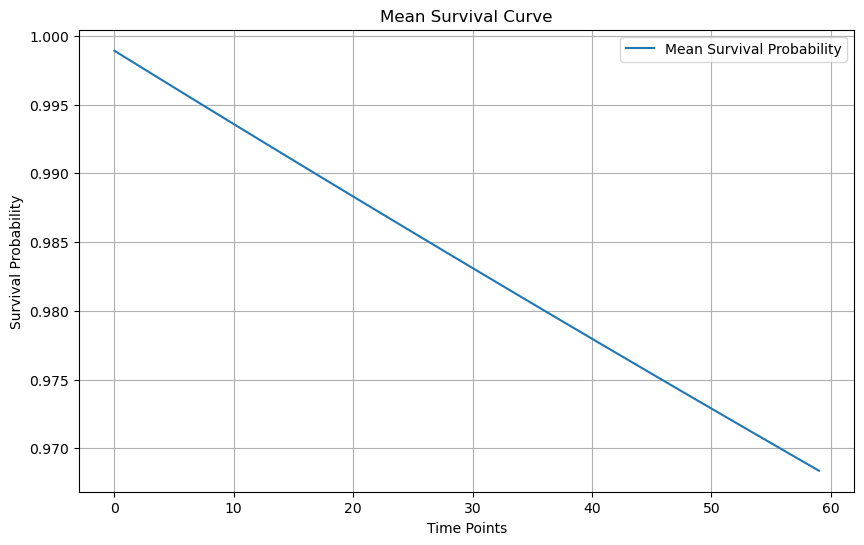

In [6]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
mean_surv_prob

array([0.9989207 , 0.998384  , 0.997848  , 0.9973126 , 0.9967779 ,
       0.996244  , 0.9957106 , 0.99517804, 0.99464595, 0.99411464,
       0.99358404, 0.99305403, 0.9925247 , 0.991996  , 0.991468  ,
       0.9909405 , 0.99041384, 0.98988765, 0.9893623 , 0.9888376 ,
       0.9883134 , 0.98778987, 0.987267  , 0.98674476, 0.9862232 ,
       0.9857024 , 0.98518205, 0.9846624 , 0.98414344, 0.9836251 ,
       0.98310745, 0.98259026, 0.9820739 , 0.981558  , 0.9810428 ,
       0.9805283 , 0.98001444, 0.9795011 , 0.97898847, 0.9784764 ,
       0.977965  , 0.9774542 , 0.97694397, 0.97643447, 0.9759255 ,
       0.97541714, 0.97490954, 0.9744024 , 0.9738959 , 0.97339004,
       0.9728848 , 0.9723801 , 0.97187614, 0.97137266, 0.9708697 ,
       0.97036755, 0.969866  , 0.9693649 , 0.96886444, 0.9683646 ],
      dtype=float32)

In [8]:
surv_pred_test_T_np

array([[0.9981337 , 0.9972066 , 0.9962812 , ..., 0.94798386, 0.9471503 ,
        0.9463181 ],
       [0.9984804 , 0.99772507, 0.99697095, ..., 0.9572533 , 0.95656157,
        0.955871  ],
       [0.9982363 , 0.99736   , 0.99648535, ..., 0.9507096 , 0.94991744,
        0.9491266 ],
       ...,
       [0.9987539 , 0.9981342 , 0.9975154 , ..., 0.96468514, 0.96410936,
        0.96353424],
       [0.9988945 , 0.99834466, 0.9977955 , ..., 0.96855146, 0.96803665,
        0.9675224 ],
       [0.9991023 , 0.99865574, 0.99820954, ..., 0.9743177 , 0.97389483,
        0.9734723 ]], dtype=float32)

In [9]:
df = pd.DataFrame(surv_pred_test_T_np)
df.to_csv('Zimbabwe_resultssurvivalFULLNEW2.csv', index=False)

In [10]:
df = pd.DataFrame(fold_ibs, columns=['fold_ibs'])
df.to_csv('fold_ibsFULLdataZimbabwesresultsNEW2.csv', index=False)

In [11]:
df = pd.DataFrame(fold_c_indices, columns=['fold_c_indices'])
df.to_csv('fold_c_indicesFULLdataZimbabwesresultsNEW2.csv', index=False)


Text(0, 0.5, 'Values')

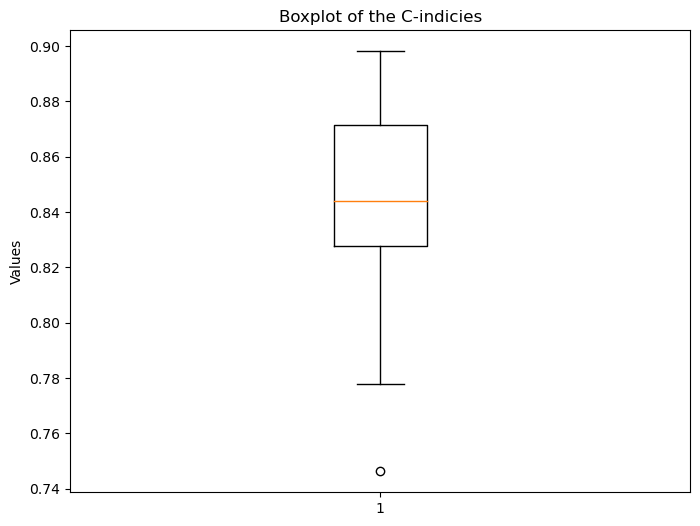

In [12]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_c_indices)
plt.title('Boxplot of the C-indicies')
plt.ylabel('Values')

Text(0, 0.5, 'Values')

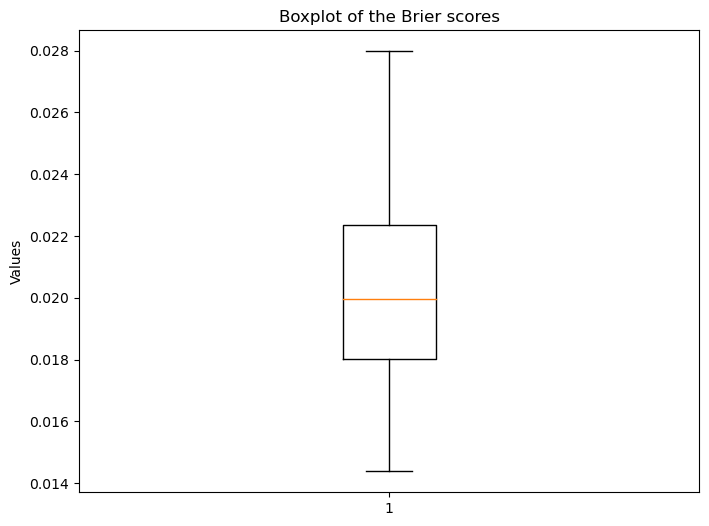

In [13]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_ibs)
plt.title('Boxplot of the Brier scores')
plt.ylabel('Values')

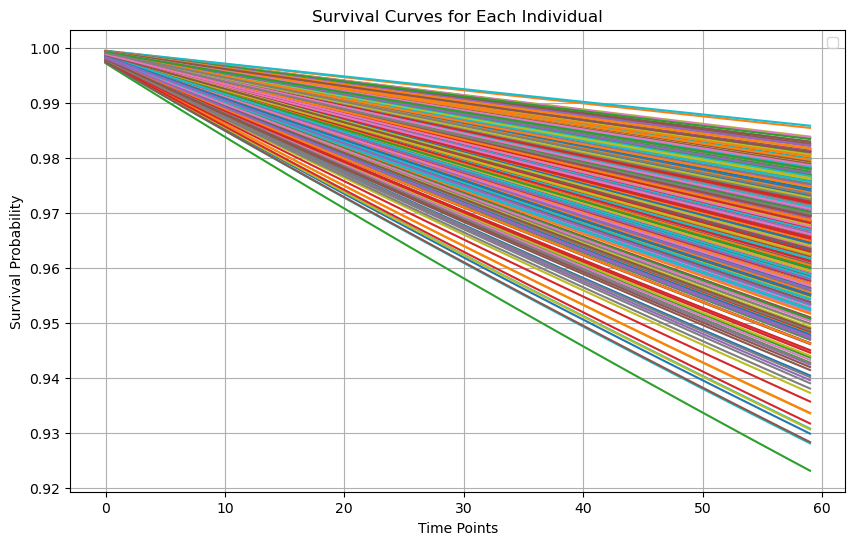

In [14]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T

# Plot each individual's survival curve
plt.figure(figsize=(10, 6))
for i in range(surv_pred_test_T.shape[0]):
    plt.plot(np.arange(surv_pred_test_T.shape[1]), surv_pred_test_T[i])

plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Survival Curves for Each Individual')
plt.legend()
plt.grid(True)
plt.show()

50

In [10]:
#train_folds
#valid_folds
#test_folds
#loader

No handles with labels found to put in legend.


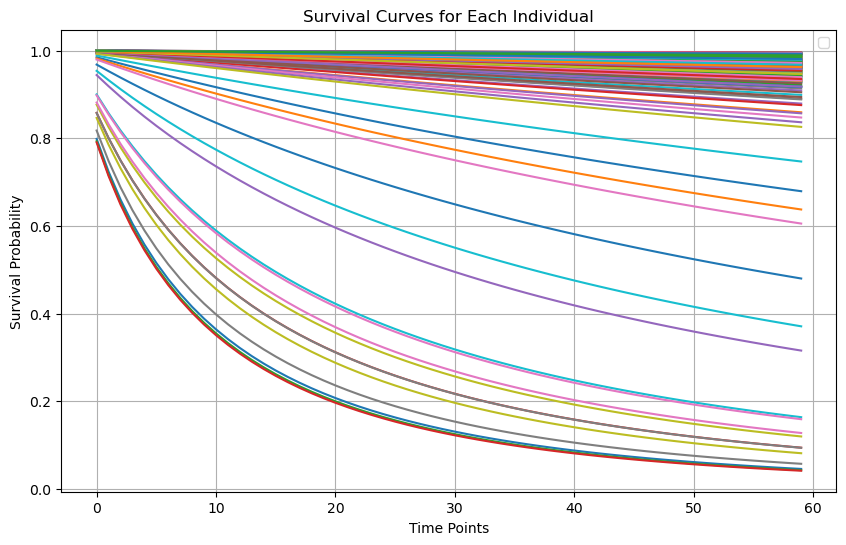

In [32]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T

# Plot each individual's survival curve
plt.figure(figsize=(10, 6))
for i in range(surv_pred_test_T.shape[0]):
    plt.plot(np.arange(surv_pred_test_T.shape[1]), surv_pred_test_T[i])

plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Survival Curves for Each Individual')
plt.legend()
plt.grid(True)
plt.show()

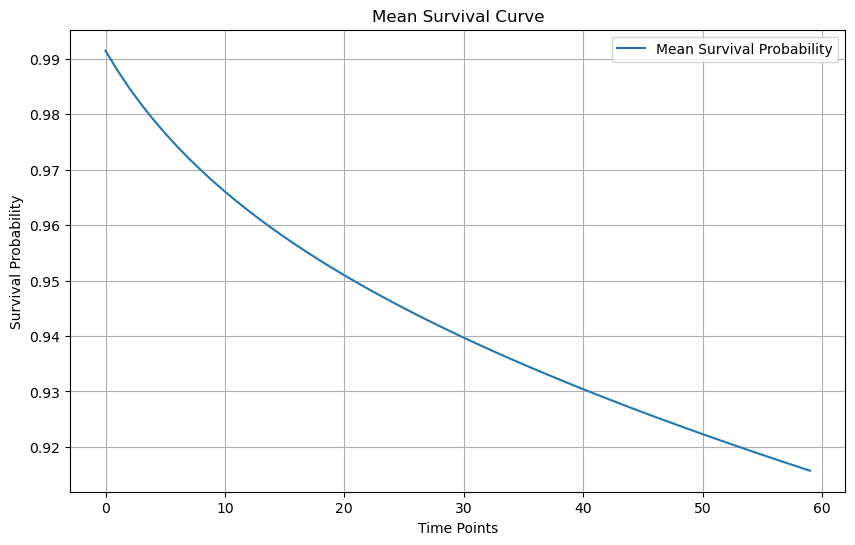

In [33]:
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Values')

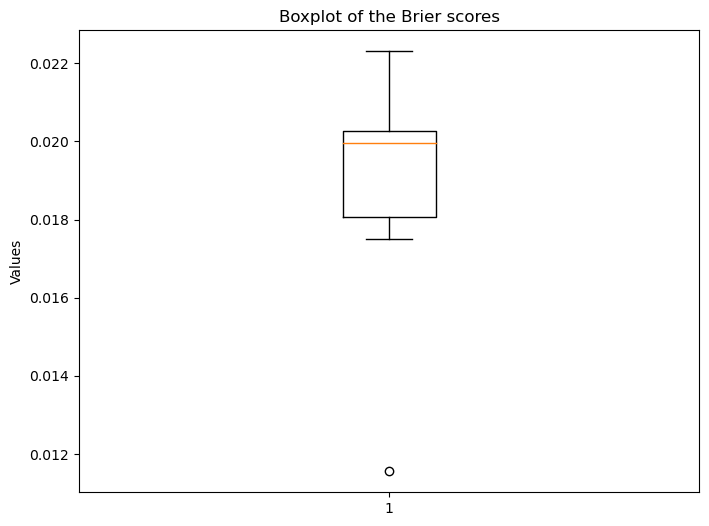

In [34]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_ibs)
plt.title('Boxplot of the Brier scores')
plt.ylabel('Values')

Text(0, 0.5, 'Values')

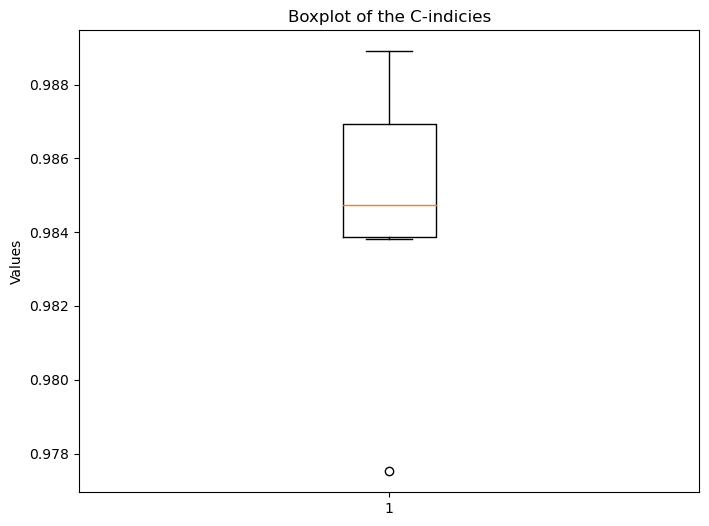

In [35]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_c_indices)
plt.title('Boxplot of the C-indicies')
plt.ylabel('Values')

In [26]:
#fold_c_indices.to_csv('Zimbabwe_cleanednewcindexresults.csv', index=False)


In [31]:
#!pip install tqdm

In [1]:
import pandas as pd

df = pd.read_csv('./nfm/data/Zimbabwe.csv')
print(df.columns)

Index(['CASEID', 'V001', 'MIDX', 'survival_time', 'Status', 'B4',
       'Mother_education', 'husband_education', 'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M4_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode', 'V206_recode',
       'V209_recode', 'M18_recode', 'V151'],
      dtype='object')


In [2]:
df.shape[0]

5877

In [3]:
df

,CASEID,V001,MIDX,survival_time,Status,B4,Mother_education,husband_education,age_group,age_first_birth,...,M4_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V206_recode,V209_recode,M18_recode,V151
0,112,1,1,57.034908,0,Male,Complete Primary,Complete Primary,30-39,below 20,...,"Ever breastfed, not currently breastfeeding",No,Biomass or Solid fuels,1,Yes,4+,1,No,Large,Male
1,122,1,1,39.819302,0,Female,Complete Primary,Complete Primary,30-39,below 20,...,"Ever breastfed, not currently breastfeeding",No,Biomass or Solid fuels,2,Yes,4+,NaN,No,Average,Male
2,142,1,1,4.008214,0,Female,Complete Primary,Complete Primary,20-29,below 20,...,Still breastfeeding,No,Biomass or Solid fuels,3,Yes,4+,NaN,Yes,Average,Male
3,142,1,2,41.954825,0,Male,Complete Primary,Complete Primary,20-29,below 20,...,"Ever breastfed, not currently breastfeeding",No,Biomass or Solid fuels,3,Yes,4+,NaN,Yes,Average,Male
4,152,1,1,26.151951,0,Male,None,Complete Primary,30-39,below 20,...,"Ever breastfed, not currently breastfeeding",No,Biomass or Solid fuels,2,No,4+,NaN,No,Large,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5872,400212,400,1,46.587269,0,Male,Complete Primary,Complete Primary,30-39,below 20,...,"Ever breastfed, not currently breastfeeding",No,Biomass or Solid fuels,1,No,3,2,No,Average,Male
5873,400222,400,1,8.870637,0,Male,Complete Primary,Complete Primary,30-39,below 20,...,Still breastfeeding,No,Biomass or Solid fuels,1,Yes,4+,NaN,Yes,Large,Male
5874,400241,400,1,47.244353,0,Female,None,Complete Primary,20-29,below 20,...,Still breastfeeding,No,Biomass or Solid fuels,0,Yes,2,NaN,No,Average,Female
5875,400271,400,1,27.104723,0,Male,None,Complete Primary,40+,below 20,...,"Ever breastfed, not currently breastfeeding",No,Biomass or Solid fuels,2,Yes,4+,1,No,Average,Female


In [4]:
file_path = './nfm/data/Zimbabwe.csv'


data_full = pd.read_csv(file_path)
features_to_remove = ['Mother_education', 'husband_education', 'V206_recode', 'M4_recode']
data_cleaned = data_full.drop(columns=features_to_remove)
Zimbabwe =data_cleaned.dropna()

In [5]:
data_full.shape[0]

5877

In [6]:
Zimbabwe.shape[0]

4436

In [7]:
Zimbabwe.to_csv('Zimbabwe_cleaned.csv', index=False)

In [8]:
import pandas as pd

# Load the Zimbabwe dataset

file_path = 'nfm/data/Zimbabwe_cleaned.csv'
Zimbabwe_df = pd.read_csv(file_path)

# Predefined encoding maps


age_group_encoding = {
    'below 20': 0, 
    '20-29': 1, 
    '30-39': 2, 
    '40+': 3
}

age_first_birth_encoding = {
    'below 20': 0, 
    '20-29': 1, 
    '30+': 2
}

drinking_water_source_encoding = {
    'Piped water': 0, 
    'Borehole': 1, 
    'Well': 2, 
    'Surface/rain/pond/lake/tank': 3, 
    'Other': 4
}

Bord_recoded_encoding = { 
    '1': 1, 
    '2-3': 2, 
    '4-6': 3,
    '7+' : 4
}

V218_recoded_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

V201_recoded_encoding = {
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

V605_recode_encoding = {
    'No': 0, 
    'Yes': 1,
    'Undecided/Never had sex' : 3
}

V130_recode_encoding = { 
    'Christians': 1, 
    'Muslim': 2, 
    'Others': 3
}

M70_recode_encoding = {
    'No': 0, 
    'Yes': 1
}

V137_recode_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

B4_recode_encoding = {
    'Female': 0, 
    'Male': 1 
}

V404_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V213_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V405_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V502_recode_encoding = {
    'Never in union': 0, 
    'Currently in union/living with a man': 1,
    'Formerly in union/living with a man': 2
}

V190_recode_encoding = {
    'Poorest': 0, 
    'Poorer': 1, 
    'Middle': 2, 
    'Richer': 3, 
    'Richest': 4
}



M3A_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V161_recode_encoding = {
    'Others': 0, 
    'Energies': 1, 
    'Biomass or Solid fuels': 2, 
    'Kerosine': 3
}

V716_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V136_recode_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}


V209_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

M18_recode_encoding = {
    'Small': 0, 
    'Average': 1,
    'Large' : 2
}

V151_recode_encoding = {
    'Female': 0, 
    'Male': 1 
}

V208_recode_encoding = { 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

# Function to apply predefined encoding to columns
def apply_predefined_encoding(df, column, encoding_map, default_value=4):
    if column in df.columns:
        df[column] = df[column].map(encoding_map).fillna(default_value).astype(int)
    return df

# Apply encodings


Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'age_group', age_group_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'age_first_birth', age_first_birth_encoding, default_value=2)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'drinking_water_source', drinking_water_source_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'BORD_recoded', Bord_recoded_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V218_recoded', V218_recoded_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V201_recoded', V201_recoded_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V605_recode', V605_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V130_recode', V130_recode_encoding, default_value=3)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'M70_recode', M70_recode_encoding, default_value=2)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V404', V404_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'B4', B4_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V213', V213_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V405', V405_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V502', V502_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V190', V190_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'M3A', M3A_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V161_recode', V161_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V716_working', V716_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V136_recode', V136_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V209_recode', V209_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'M18_recode', M18_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V151', V151_recode_encoding)
Zimbabwe_df = apply_predefined_encoding(Zimbabwe_df, 'V208_recoded', V208_recode_encoding)

# Update column names
Zimbabwe_df.columns = ['CASEID', 'V001', 'MIDX', 'survival_time', 'Status', 'B4',
         'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']

# Display the preprocessed dataset
Zimbabwe_df.head()


,CASEID,V001,MIDX,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,112,1,1,57.034908,0,1,2,0,2,3,...,1,1,0,2,1,1,4,0,2,1
1,122,1,1,39.819302,0,0,2,0,2,3,...,1,1,0,2,2,1,4,0,1,1
2,142,1,1,4.008214,0,0,1,0,2,2,...,1,1,0,2,3,1,4,1,1,1
3,152,1,1,26.151951,0,1,2,0,2,3,...,1,1,0,2,2,0,4,0,2,1
4,162,1,1,44.616016,0,0,2,0,2,3,...,1,1,0,2,1,0,4,0,2,1


In [9]:
Zimbabwe_df.shape[0]

4436

In [10]:
Zimbabwe_df.to_csv('Zimbabwe_cleanednew.csv', index=False)

In [ ]:
df = pd.DataFrame(fold_ibs, columns=['fold_ibs'])
df.to_csv('fold_ibsZimbabwe_cleanednewfold_ibsresults.csv', index=False)

In [ ]:
df = pd.DataFrame(fold_c_indices, columns=['fold_c_indices'])
df.to_csv('fold_c_indicesZimbabwe_cleanednewcindexresults.csv', index=False)

In [ ]:
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df = pd.DataFrame(surv_pred_test_T_np)

In [ ]:
df.to_csv('Zimbabwe_cleanednewsurvivalresults.csv', index=False)